# Stoner-Wohlfarth Particle
We are simulating the hard-axis loop of a Stoner-Wohlfarth particle with uniaxial anisotorpy with $K$ = 100 kJ/m$^3$.

## Simulation
### Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

import neuralmag as nm

2025-05-12 23:32:23 NeuralMag:INFO [NeuralMag] Version 0.9.1


### Initialize state, mesh and material parameters
In order to simulate a Stoner-Wohlfarth particle, we setup a small 2 x 2 x 2 cell mesh whose size is well below the single-domain limit. As material parameters we choose the saturation magnetization $M_s$ and the exchange constant $A$ equal to those of Permalloy, but we add a uniaxial anisotropy in z-axis with anisotropy constant $K$ = 100 kJ/m$^3$ with a slight tilt into the x-direction in order to avoid an unstable equilibrium at saturation.

In [2]:
mesh = nm.Mesh((2, 2, 2), (5e-9, 5e-9, 5e-9))
state = nm.State(mesh)

state.material.Ms = 8e5
state.material.A = 1.3e-11
state.material.Ku = 1e5
state.material.Ku_axis = [0.01, 0, 1]
state.material.alpha = 1.0

2025-05-12 23:32:23 NeuralMag:INFO [Mesh] 3D, 2 x 2 x 2 (size = 5e-09 x 5e-09 x 5e-09)
2025-05-12 23:32:24 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-05-12 23:32:24 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-05-12 23:32:24 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-05-12 23:32:24 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)


### Initialize initial magnetization

In [3]:
state.m = nm.VectorFunction(state).fill((-1, 0, 0))

### Register effective field
We register an effective field comprised of an exchange field, an uniaxial anisotropy and en external field the sweeps from $(-1.5 H_c, 0, 0)$ to $(+1.5 H_c, 0, 0)$ within 20 ns with $H_c$ being the the coercive field of the particle.

In [4]:
nm.ExchangeField().register(state, "exchange")
nm.UniaxialAnisotropyField().register(state, "aniso")
Hc = 2 * 1e5 / (constants.mu_0 * 8e5)
nm.ExternalField(
    lambda t: state.tensor([1.5 * (t - 10e-9) / 10e-9 * Hc, 0, 0])
).register(state, "external")
nm.TotalField("exchange", "aniso", "external").register(state)

2025-05-12 23:32:24 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-05-12 23:32:24 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-05-12 23:32:24 NeuralMag:INFO [ExternalField] Register state methods (field: 'h_external', energy: 'E_external')
2025-05-12 23:32:24 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


### Perform time integration

In [5]:
llg = nm.LLGSolver(state)
logger = nm.Logger(
    "stoner-wohlfarth-hysteresis",
    ["t", "h_external", "m", "E"],
    ["m"],
    fields_every=100,
)
while state.t < 20e-9:
    logger.log(state)
    llg.step(2e-10)

2025-05-12 23:32:24 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2025-05-12 23:32:28 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 0s
2025-05-12 23:32:44 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 2e-10s
2025-05-12 23:32:44 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 4e-10s
2025-05-12 23:32:44 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 6e-10s
2025-05-12 23:32:44 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 8e-10s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 1e-09s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 1.2e-09s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 1.4e-09s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 1.6e-09s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 1.8e-09s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSolverJAX] Step: dt = 2e-10s, t = 2e-09s
2025-05-12 23:32:45 NeuralMag:INFO [LLGSol

### Plot the result

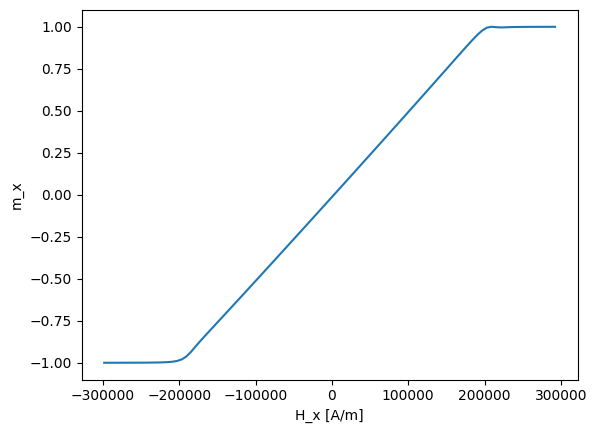

In [6]:
data = np.loadtxt("stoner-wohlfarth-hysteresis/log.dat")
plt.plot(data[:, 1], data[:, 4])
plt.xlabel("H_x [A/m]")
plt.ylabel("m_x")
plt.show()